In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

import sys
import os
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = './classificacao_Q2.csv'

df = pd.read_csv(data)

In [3]:
df.head()

,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,target
0,-1.39917,0.96108,-0.36145,0.26092,2.78953,-1.55046,-0.79886,0.24304,1.51733,-0.03357,-1.51127,-0.97444,-0.01934,0
1,-2.48564,1.24529,-0.39431,1.06648,1.71957,-0.60296,-2.35698,-2.31878,0.95555,-2.00420,-0.75294,-3.64680,-0.55923,0
2,-0.57025,0.65495,-0.73706,0.22444,-0.44094,-0.42596,0.44267,-1.74196,-0.06599,-0.36783,0.93065,-0.72392,0.37139,0
3,2.10165,1.46236,-0.25678,2.58908,-3.40158,2.43561,0.74701,-0.65229,-0.45497,-1.57951,2.07367,1.86435,-0.37664,1
4,3.01588,-2.50913,-2.01442,2.10296,-3.05465,5.38227,0.46846,1.57586,3.02176,-0.86271,-1.14418,-0.89712,0.61823,1


In [ ]:
X = df.drop(['target'], axis=1)
y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

X_train.shape, X_test.shape


((2000, 13), (500, 13))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Construir modelo de Regressão Logística
print("=== Construindo Modelo de Regressão Logística ===")

# Criar o modelo com regularização L2 (Ridge) e fator de regularização C=1e-5
# Nota: C é o inverso do parâmetro de regularização (C = 1/lambda)
# C pequeno = mais regularização
logistic_model = LogisticRegression(
    penalty='l2',           # Regularização L2 (Ridge)
    C=1e-5,                # Fator de regularização (muito pequeno = muita regularização)
    random_state=42,        # Para reprodutibilidade
    max_iter=1000          # Máximo de iterações para convergência
)

# Treinar o modelo
logistic_model.fit(X_train, y_train)

print("✅ Modelo de Regressão Logística treinado com sucesso!")
print(f"📊 Parâmetros do modelo:")
print(f"   - Regularização: L2 (Ridge)")
print(f"   - Fator C: {logistic_model.C}")
print(f"   - Iterações para convergência: {logistic_model.n_iter_[0]}")

# Fazer previsões (probabilidades)
y_train_proba = logistic_model.predict_proba(X_train)[:, 1]  # Probabilidade da classe positiva
y_test_proba = logistic_model.predict_proba(X_test)[:, 1]    # Probabilidade da classe positiva

# Fazer previsões (classes)
y_train_pred = logistic_model.predict(X_train)
y_test_pred = logistic_model.predict(X_test)

print("\n🎯 Previsões realizadas com sucesso!")

=== Construindo Modelo de Regressão Logística ===
✅ Modelo de Regressão Logística treinado com sucesso!
📊 Parâmetros do modelo:
   - Regularização: L2 (Ridge)
   - Fator C: 1e-05
   - Iterações para convergência: 10

🎯 Previsões realizadas com sucesso!


=== Avaliação da Métrica AUC ===
🎯 AUC-ROC (Treino): 0.8508
🎯 AUC-ROC (Teste): 0.8596

📊 Diferença AUC (Treino - Teste): -0.0088
✅ Modelo bem balanceado


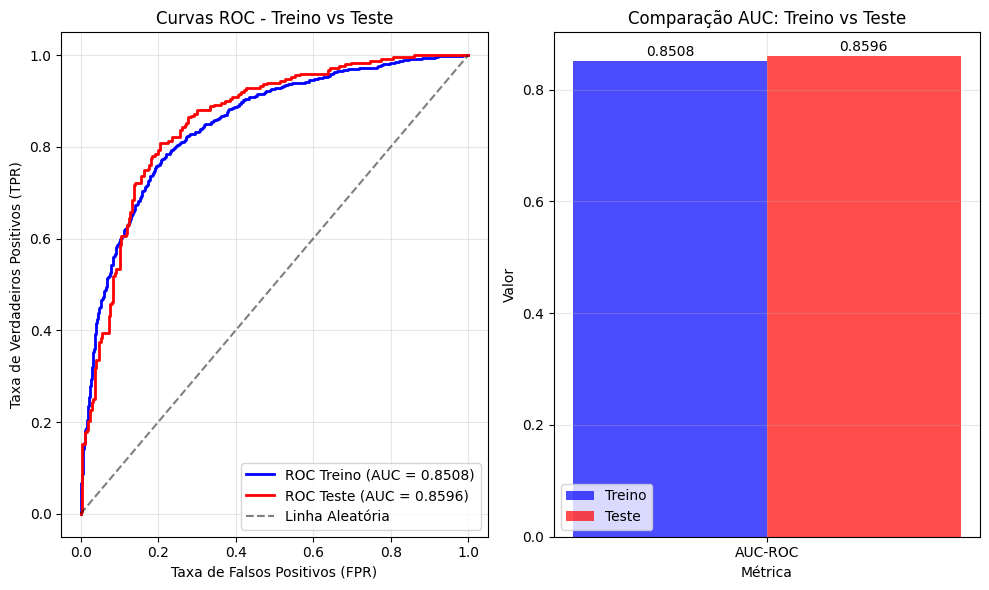


📈 Interpretação da Métrica AUC:
• AUC = 1.0: Classificador perfeito
• AUC = 0.5: Classificador aleatório
• AUC < 0.5: Classificador pior que aleatório
• AUC > 0.7: Considerado bom
• AUC > 0.8: Considerado muito bom
• AUC > 0.9: Considerado excelente


In [7]:
# Calcular AUC para treino e teste
print("=== Avaliação da Métrica AUC ===")

# Calcular AUC-ROC para treino
auc_train = roc_auc_score(y_train, y_train_proba)
print(f"🎯 AUC-ROC (Treino): {auc_train:.4f}")

# Calcular AUC-ROC para teste
auc_test = roc_auc_score(y_test, y_test_proba)
print(f"🎯 AUC-ROC (Teste): {auc_test:.4f}")

# Diferença entre treino e teste (indicador de overfitting)
diff_auc = auc_train - auc_test
print(f"\n📊 Diferença AUC (Treino - Teste): {diff_auc:.4f}")

if diff_auc > 0.05:
    print("⚠️  Possível overfitting (diferença > 0.05)")
elif diff_auc < -0.05:
    print("⚠️  Possível underfitting (AUC teste > treino)")
else:
    print("✅ Modelo bem balanceado")

# Calcular curvas ROC para plotagem
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

# Plotar curvas ROC
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.plot(fpr_train, tpr_train, color='blue', linewidth=2, 
         label=f'ROC Treino (AUC = {auc_train:.4f})')
plt.plot(fpr_test, tpr_test, color='red', linewidth=2, 
         label=f'ROC Teste (AUC = {auc_test:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Linha Aleatória')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC - Treino vs Teste')
plt.legend()
plt.grid(True, alpha=0.3)

# Plotar comparação das métricas
plt.subplot(1, 2, 2)
metrics = ['AUC-ROC']
train_values = [auc_train]
test_values = [auc_test]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, train_values, width, label='Treino', color='blue', alpha=0.7)
plt.bar(x + width/2, test_values, width, label='Teste', color='red', alpha=0.7)

plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.title('Comparação AUC: Treino vs Teste')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)

# Adicionar valores nas barras
for i, (train_val, test_val) in enumerate(zip(train_values, test_values)):
    plt.text(i - width/2, train_val + 0.01, f'{train_val:.4f}', ha='center', fontsize=10)
    plt.text(i + width/2, test_val + 0.01, f'{test_val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📈 Interpretação da Métrica AUC:")
print("• AUC = 1.0: Classificador perfeito")
print("• AUC = 0.5: Classificador aleatório")
print("• AUC < 0.5: Classificador pior que aleatório")
print("• AUC > 0.7: Considerado bom")
print("• AUC > 0.8: Considerado muito bom")
print("• AUC > 0.9: Considerado excelente")

=== Análise Complementar ===
📊 Métricas de Classificação:
   Acurácia - Treino: 0.7725 | Teste: 0.7880
   Precisão - Treino: 0.7743 | Teste: 0.7921
   Recall   - Treino: 0.7725 | Teste: 0.7880
   F1-Score - Treino: 0.7720 | Teste: 0.7872

📋 Matriz de Confusão (Teste):
[[181  68]
 [ 38 213]]


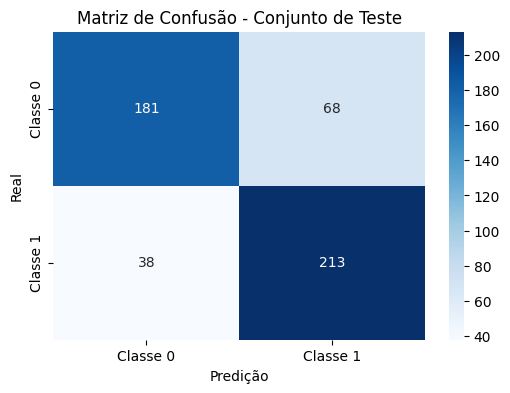


🎯 RESUMO DO MODELO DE REGRESSÃO LOGÍSTICA
✅ Regularização: L2 (Ridge)
✅ Fator de regularização C: 1e-05
✅ AUC-ROC Treino: 0.8508
✅ AUC-ROC Teste: 0.8596
✅ Diferença AUC: -0.0088
✅ Acurácia Teste: 0.7880


In [8]:
# Análise complementar com outras métricas
print("=== Análise Complementar ===")

# Importar métricas adicionais
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calcular métricas adicionais
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

precision_train = precision_score(y_train, y_train_pred, average='weighted')
precision_test = precision_score(y_test, y_test_pred, average='weighted')

recall_train = recall_score(y_train, y_train_pred, average='weighted')
recall_test = recall_score(y_test, y_test_pred, average='weighted')

f1_train = f1_score(y_train, y_train_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

print("📊 Métricas de Classificação:")
print(f"   Acurácia - Treino: {accuracy_train:.4f} | Teste: {accuracy_test:.4f}")
print(f"   Precisão - Treino: {precision_train:.4f} | Teste: {precision_test:.4f}")
print(f"   Recall   - Treino: {recall_train:.4f} | Teste: {recall_test:.4f}")
print(f"   F1-Score - Treino: {f1_train:.4f} | Teste: {f1_test:.4f}")

# Matriz de confusão
print("\n📋 Matriz de Confusão (Teste):")
cm_test = confusion_matrix(y_test, y_test_pred)
print(cm_test)

# Plotar matriz de confusão
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Classe 0', 'Classe 1'], 
            yticklabels=['Classe 0', 'Classe 1'])
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.show()

# Resumo final
print("\n" + "="*50)
print("🎯 RESUMO DO MODELO DE REGRESSÃO LOGÍSTICA")
print("="*50)
print(f"✅ Regularização: L2 (Ridge)")
print(f"✅ Fator de regularização C: {logistic_model.C}")
print(f"✅ AUC-ROC Treino: {auc_train:.4f}")
print(f"✅ AUC-ROC Teste: {auc_test:.4f}")
print(f"✅ Diferença AUC: {diff_auc:.4f}")
print(f"✅ Acurácia Teste: {accuracy_test:.4f}")
print("="*50)